In [ ]:
 # Install required libraries
!pip install pandas plotly prophet

In [ ]:
import pandas as pd
import plotly.express as px
from prophet import Prophet
import plotly.graph_objects as go

In [ ]:
import zipfile
import os

zip_file_path = "/content/Project-COVID-19-Analysis-1.zip"
extracted_dir = "/content/extracted_data"
os.makedirs(extracted_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extract('covid_19_clean_complete.csv', extracted_dir)

extracted_file_path = os.path.join(extracted_dir, 'covid_19_clean_complete.csv')

In [ ]:
# load the dataset
file_path = extracted_file_path
df = pd.read_csv(file_path)
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
# Data overview
print("Columns:", df.columns.tolist())
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())
print("\nSample data:\n", df.head(3))

Columns: ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']

Date range: 2020-01-22 to 2020-07-27

Sample data:
   Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  


In [ ]:
# data processing
df['Date'] = pd.to_datetime(df['Date'])
global_df = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
global_df['Active'] = global_df['Confirmed'] - global_df['Deaths'] - global_df['Recovered']


In [ ]:
# global
fig = px.line(global_df, x='Date', y=['Confirmed', 'Recovered', 'Deaths'],
              title=' Global COVID-19 Trends Over Time',
              labels={'value': 'Number of Cases', 'variable': 'Case Type'})
fig.update_layout(template='plotly_dark')
fig.show()


In [ ]:
# Indian
india_df = df[df['Country/Region'] == 'India']
india_trend = india_df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
india_trend['Active'] = india_trend['Confirmed'] - india_trend['Deaths'] - india_trend['Recovered']

fig2 = px.line(india_trend, x='Date', y=['Confirmed', 'Recovered', 'Deaths'],
               title='🇮🇳 COVID-19 Trend in India',
               labels={'value': 'Number of Cases', 'variable': 'Case Type'})
fig2.update_layout(template='plotly_dark')
fig2.show()

In [ ]:
# new cases in india
india_trend['New Confirmed'] = india_trend['Confirmed'].diff().fillna(0)
fig3 = px.bar(india_trend, x='Date', y='New Confirmed',
              title='📈 Daily New Confirmed Cases in India',
              labels={'New Confirmed': 'New Cases per Day'})
fig3.update_layout(template='plotly_dark')
fig3.show()

In [ ]:
forecast_df = india_trend[['Date', 'Confirmed']].rename(columns={'Date': 'ds', 'Confirmed': 'y'})


In [ ]:
model = Prophet(interval_width=0.95)
model.fit(forecast_df)

future = model.make_future_dataframe(periods=7)  # Predict 7 days ahead
forecast = model.predict(future)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdu2v5ysa/yzne_stf.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdu2v5ysa/e3jf9aeq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=25472', 'data', 'file=/tmp/tmpdu2v5ysa/yzne_stf.json', 'init=/tmp/tmpdu2v5ysa/e3jf9aeq.json', 'output', 'file=/tmp/tmpdu2v5ysa/prophet_modelhhw5litl/prophet_model-20251027172336.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:23:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:23:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


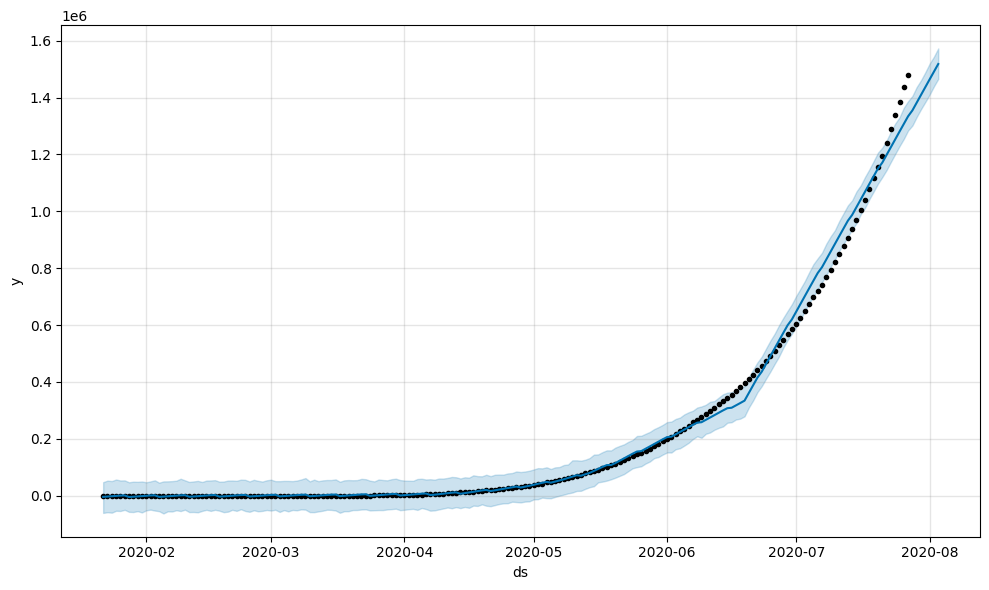

In [ ]:
fig4 = model.plot(forecast)
fig4.show()



In [ ]:

fig5 = px.line(forecast, x='ds', y='yhat', title=' 7-Day Forecast of COVID-19 Confirmed Cases (India)')
fig5.add_trace(go.Scatter(x=forecast_df['ds'], y=forecast_df['y'],
                          mode='lines', name='Actual', line=dict(color='orange')))
fig5.update_layout(template='plotly_dark')
fig5.show()

In [ ]:
forecast.tail(7)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
188,2020-07-28,1.354796e+06,1.301608e+06,1.405508e+06
189,2020-07-29,1.381919e+06,1.331644e+06,1.437019e+06
190,2020-07-30,1.409255e+06,1.359029e+06,1.460721e+06
191,2020-07-31,1.436718e+06,1.384249e+06,1.488767e+06
192,2020-08-01,1.463907e+06,1.410288e+06,1.519106e+06
193,2020-08-02,1.491236e+06,1.439282e+06,1.543641e+06
194,2020-08-03,1.517933e+06,1.465400e+06,1.572716e+06


In [ ]:
latest = india_trend.iloc[-1]
print("\n--- SUMMARY REPORT ---")
print(f"Latest Date in Data: {latest['Date'].date()}")
print(f"Confirmed Cases: {latest['Confirmed']:,}")
print(f"Recovered Cases: {latest['Recovered']:,}")
print(f"Deaths: {latest['Deaths']:,}")
print(f"Active Cases: {latest['Active']:,}")

recovery_rate = (latest['Recovered'] / latest['Confirmed']) * 100
fatality_rate = (latest['Deaths'] / latest['Confirmed']) * 100
print(f"Recovery Rate: {recovery_rate:.2f}%")
print(f"Fatality Rate: {fatality_rate:.2f}%")

print("\nObservation:")
print("• The confirmed and recovered cases are steadily increasing.")
print("• Daily new cases show waves indicating multiple surges.")
print("• Forecast suggests the trend continues to rise in the next 7 days.")


--- SUMMARY REPORT ---
Latest Date in Data: 2020-07-27
Confirmed Cases: 1,480,073
Recovered Cases: 951,166
Deaths: 33,408
Active Cases: 495,499
Recovery Rate: 64.26%
Fatality Rate: 2.26%

Observation:
• The confirmed and recovered cases are steadily increasing.
• Daily new cases show waves indicating multiple surges.
• Forecast suggests the trend continues to rise in the next 7 days.


In [ ]:
!pip install prophet
from prophet import Prophet

# Prepare data for Prophet
# Prophet requires 'ds' as the date column and 'y' as the target variable (Confirmed cases)
forecast_df = df.groupby('Date')['Confirmed'].sum().reset_index()
forecast_df = forecast_df.rename(columns={'Date': 'ds', 'Confirmed': 'y'})

# Initialize Prophet model
model = Prophet(interval_width=0.95)
model.fit(forecast_df)

# Create a dataframe to hold future predictions of next 7 days
future = model.make_future_dataframe(periods=7)

# Predict future cases
forecast = model.predict(future)

# Display forecasted data (7-day prediction)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

# Plot forecast using Prophet
from prophet.plot import plot_plotly
fig = plot_plotly(model, forecast)
fig.update_layout(title="COVID-19 Forecast for Next 7 Days", xaxis_title="Date", yaxis_title="Predicted Confirmed Cases")
fig.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdu2v5ysa/gvtlgrys.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdu2v5ysa/c6yoigsn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=99093', 'data', 'file=/tmp/tmpdu2v5ysa/gvtlgrys.json', 'init=/tmp/tmpdu2v5ysa/c6yoigsn.json', 'output', 'file=/tmp/tmpdu2v5ysa/prophet_modelkgpxc7nn/prophet_model-20251027175505.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:55:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:55:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
